# **Описание файла**

В данном ноутбуке реализован этап построения базовой (baseline) модели для задачи классификации клиентов по факту открытия депозита. Цель этапа — сформировать воспроизводимый пайплайн предобработки данных и получить объективный ориентир качества, относительно которого в дальнейшем будут оцениваться улучшения (новые признаки, ансамбли, подбор гиперпараметров).

На текущем этапе решаются следующие задачи:

- **Предобработка данных**: очистка от очевидных аномалий, обработка пропусков, приведение типов и кодирование категориальных признаков с сохранением семантики (в том числе бинарного признака `has_any_credit`).
- **Подготовка выборок**: формирование обучающей и тестовой подвыборок с учётом дисбаланса классов, применение стратификации по целевой переменной, а при необходимости — кросс-валидация с `StratifiedKFold`.
- **Построение baseline-моделей**: реализация простых, но информативных моделей, позволяющих оценить принципиальную предсказуемость целевой переменной на имеющихся признаках:
  - `DummyClassifier` с различными стратегиями (в первую очередь `most_frequent` как наивный ориентир при дисбалансе);
  - логистическая регрессия (`LogisticRegression`) как интерпретируемая базовая модель;
  - простое дерево решений небольшой глубины (`DecisionTreeClassifier`) для быстрой оценки нелинейностей.
- **Оценка качества**: расчёт ключевых метрик (accuracy, F1, ROC‑AUC, PR‑AUC), анализ матрицы ошибок и сравнение результатов моделей между собой и с наивной стратегией.

Полученные результаты будут использованы как точка отсчёта для последующих экспериментов: добавления новых признаков, применения методов борьбы с дисбалансом (SMOTE, `class_weight`), а также более сложных моделей (RandomForest, LGBMClassifier). Все этапы реализованы с учётом воспроизводимости: зафиксированы `random_state`, последовательность шагов предобработки и схема валидации.


# **Импорт основных библиотек**

In [40]:
# импорт модулей/библиотек для обработки данных
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
import seaborn as sns
from my_def_and_plot import *
from plots import *
import random
from scipy.stats import randint, uniform, loguniform
import lightgbm as lgb


In [2]:
# импорт необходимого окружения для визуализации
# отключим предупреждения Anaconda
import warnings
warnings.simplefilter('ignore')

# будем отображать графики прямо в jupyter'e
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
#графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 

#увеличим дефолтный размер графиков
from pylab import rcParams
rcParams['figure.figsize'] = 8, 5
import pandas as pd

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

# **1. Препроцессинг данных**

**Препроцессинг данных можно разделить на две основные категории:**

* Общие преобразования – применяются ко всему датасету до разделения на train и test.
* Индивидуальные преобразования – выполняются отдельно для тренировочной и тестовой выборок.

`Почему такое разделение необходимо?`

Некоторые преобразования требуют расчета статистик (например, замена пропусков медианой, стандартизация, частотное кодирование) или даже обучения вспомогательных моделей (например, KNN для импутации пропущенных значений). Если применить такие преобразования ко всему датасету до разделения, это приведет к data leakage (утечке данных).

`Что такое data leakage и чем он опасен?`

Data leakage возникает, когда информация из тестового набора неявно влияет на preprocessing тренировочных данных (например, при расчете среднего или обучении encoder'а). В результате:

Модель получает доступ к данным, которых не должно "знать" в реальных условиях;
Оценки качества становятся завышенными, но на новых данных модель работает хуже.
Как избежать утечки данных?

Сначала разделять данные на train и test (или использовать кросс-валидацию).
Обучать preprocessing-алгоритмы (импутеры, энкодеры, скейлеры) только на train.
Применять обученные преобразования к test, без пересчета статистик.
Крайне рекомендуется использовать пайплайны (например, sklearn.pipeline.Pipeline), которые автоматически следят за корректным порядком преобразований.

`Какие преобразования можно применять ко всему датасету?`

Те, что не зависят от статистик и не требуют обучения:

* Удаление дубликатов;
* Исправление очевидных аномалий (например, отрицательный возраст);
* Разовые преобразования (изменение формата даты, переименование столбцов);
* Фильтрация строк/столбцов, не связанная с целевой переменной;
* Такой подход помогает избежать дублирования кода, сохраняя при этом валидность эксперимента.

## **1.1 Общие преобразования**

In [4]:
# выгрузка данных
df = pd.read_csv('bank.csv')
# создадим независимую копию исходного DataFrame df
df_preprocessed = df.copy()

### **1.1.1 Работа по признаку balance**

* balance имеет огромный разброс (от −6847 до 81 204) и большую дисперсия — почти наверняка есть сильные выбросы. Отрицательный баланс тоже интересен: это долг/овердрафт или ошибка;
* отрициательные значения не удаляем, а создаем новые признаки для модели.

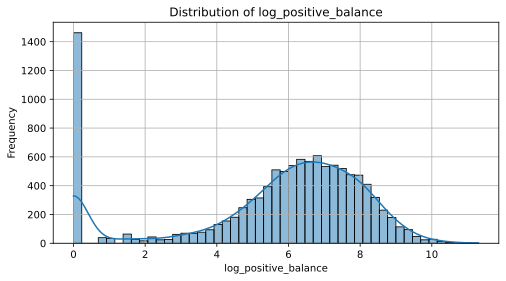

In [5]:
df_preprocessed['has_debt'] = (df_preprocessed['balance'] < 0).astype(int)
df_preprocessed['debt_amount'] = df_preprocessed['balance'].clip(upper=0).abs()      # размер долга
df_preprocessed['positive_balance'] = df_preprocessed['balance'].clip(lower=0)       # только положительный баланс

# Логарифмируем только положительные части (там, где есть смысл)
df_preprocessed['log_positive_balance'] = np.log1p(df_preprocessed['positive_balance'])
df_preprocessed['log_debt_amount'] = np.log1p(df_preprocessed['debt_amount'])

# удалим balance из датафремйа, чтоб нивелировать правостороний перекос
df_preprocessed = df_preprocessed.drop(columns=['balance'])

plot_hist_numeric(df_preprocessed, 'log_positive_balance')

### **1.1.2 Работа по признаку duration**

In [6]:
# удалим duration из датафремйа, чтоб нивелировать правостороний перекос
df_preprocessed = df_preprocessed.drop(columns=['duration'])

**Информация о результате звонка, которую невозможно знать до того, как звонок закончится. Необходимо удалить данный признак**

### **1.1.3 Работа по признаку age**

* в данном признаке фиксируем выбросы, которые необходимо удлаить;
* гистограмма скошена вправо, стоит провести логарифмирование.

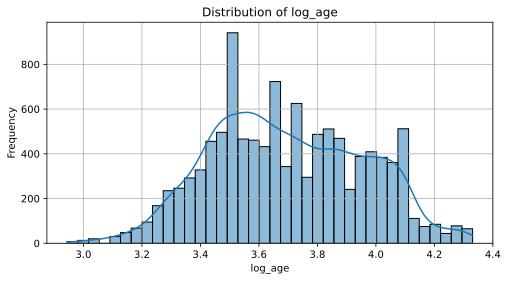

In [7]:
# удаляем выбросы
df_preprocessed = df_preprocessed[df_preprocessed['age']<=75]

# логарифмирование признака 
df_preprocessed['log_age'] = np.log1p(df_preprocessed['age'])

# удалим duration из датафремйа, чтоб нивелировать правостороний перекос
df_preprocessed = df_preprocessed.drop(columns=['age'])

# вывод гистограммы
plot_hist_numeric(df_preprocessed, 'log_age')

### **1.1.4 Работа по признаку campaign**

* фиксируем выбросы: по формуле статистки, верхний/нижний "ус" = медиана +- 1,5*IQR = (0.10, 3.10), считаю, что клиентов, которые выходят за данный интервал стоит удалить...

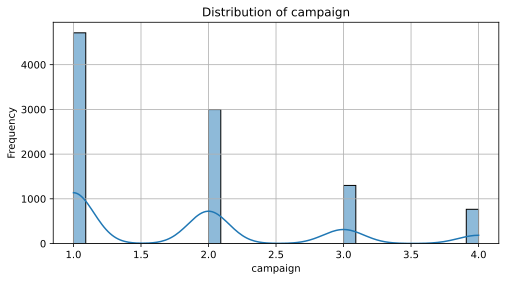

In [8]:
# удалим клиентов, с которыми контактировали более 4 раз за кампанию 
df_preprocessed = df_preprocessed[df_preprocessed['campaign']<=4]
# вывод гистограммы
plot_hist_numeric(df_preprocessed, 'campaign')


### **1.1.5 Работа по признаку job**

In [9]:
# проведем объединение малых групп клиентов в подгруппу outher

job_counts = df_preprocessed['job'].value_counts(normalize = True) # находим доли специальностей клиентов

list_smol_job = job_counts[job_counts <= 0.06].index.tolist() # список названий специальностей с маленькой долей

df_preprocessed.loc[df_preprocessed['job'].isin(list_smol_job), 'job'] = 'other' # замена

df_preprocessed['job'].value_counts(normalize = True) # прверка замены

job
management     0.229793
other          0.221813
blue-collar    0.177000
technician     0.165439
admin.         0.122775
services       0.083180
Name: proportion, dtype: float64

### **1.1.6 Работа по признаку ededucation**

In [10]:
# в признаке ededucation 'unknown' надо объединить с 'primary'
df_preprocessed['education'] = df_preprocessed['education'].replace('unknown', 'primary')

df_preprocessed['education'].value_counts(normalize = True) # прверка замены

education
secondary    0.497238
tertiary     0.333947
primary      0.168815
Name: proportion, dtype: float64

### **1.1.7 Работа по признаку default**

* в признаке default жуткий дисбаланс классов, легче удалить данный признак, ибо он даже не коррелирует с целевым признаком...

In [11]:
# удаление признака 'default'
df_preprocessed = df_preprocessed.drop('default', axis=1)

## **1.2 Разбиение датасета**

In [12]:
# разбиваем признаковое описание на целевой и входные признаки
X = df_preprocessed.drop('deposit', axis=1)
y = df_preprocessed['deposit'].map({'no': 0, 'yes': 1})

# разбиваем данные на тренировочную и тестовую выборки
# Разбиваем данные на train и test с соотношением 80 на 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED, 
    # stratify сохраняет пропорции классов как в исходных данных:
    # 1) Гарантирует, что в train и test попадут представители всех классов
    # 2) Особенно важно для несбалансированных данных
    # 3) Позволяет получить репрезентативные выборки
    # 4) Исключает случайное отсутствие редких классов в подвыборках
    stratify=y  
)

# проверка деления
print(X_train.shape, y_train.shape)
print( X_test.shape, y_test.shape)

(7819, 18) (7819,)
(1955, 18) (1955,)


## **1.3 Индивидуальные преобразования**

In [13]:
# разделим признаки на количесвтенные и качественные признаки
numerical_features = [x for x in df_preprocessed.columns if pd.api.types.is_numeric_dtype(df_preprocessed[x])]
categorical_features = list(set([x for x in df_preprocessed.columns if not pd.api.types.is_numeric_dtype(df_preprocessed[x])]) - set(['deposit']))

# проверка наличия дополнительных признаков
print(numerical_features)
print(categorical_features)

['day', 'campaign', 'pdays', 'previous', 'has_debt', 'debt_amount', 'positive_balance', 'log_positive_balance', 'log_debt_amount', 'log_age']
['education', 'marital', 'month', 'housing', 'loan', 'contact', 'job', 'poutcome']


In [14]:
# выведем уникальные значения признаков
for i in categorical_features:
    print(f'Уникальные значения признака {i.upper()}:')
    print(df_preprocessed[i].unique())

Уникальные значения признака EDUCATION:
['secondary' 'tertiary' 'primary']
Уникальные значения признака MARITAL:
['married' 'single' 'divorced']
Уникальные значения признака MONTH:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Уникальные значения признака HOUSING:
['yes' 'no']
Уникальные значения признака LOAN:
['no' 'yes']
Уникальные значения признака CONTACT:
['unknown' 'cellular' 'telephone']
Уникальные значения признака JOB:
['admin.' 'technician' 'services' 'management' 'other' 'blue-collar']
Уникальные значения признака POUTCOME:
['unknown' 'other' 'failure' 'success']


**Представленные качесвтенные признаки кодируем следующим образомб, а количественные признаки стандартизируем:**

* One‑Hot Encoding — для номинальных признаков без порядка: JOB, CONTACT, POUTCOME, MARITAL;
* Ordinal Encoding — когда категории можно упорядочить по смыслу/рангу: EDUCATION, MONTH;
* Binary (0/1) — для бинарных признаков (yes/no, true/false): HOUSING, LOAN.

In [15]:
# группы признаков по кодированию
cat_ohe = ['job', 'marital', 'contact', 'poutcome']
cat_ordinal = ['education', 'month']
cat_binary = ['housing', 'loan']

# значения качетсвенных признаков 
edu_order = ['primary', 'secondary', 'tertiary']
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# количественные признаки
num_scale = [
    'day', 'campaign', 'pdays', 'previous',
    'debt_amount', 'positive_balance',
    'log_positive_balance', 'log_debt_amount', 'log_age'
]

passthrough_cols = ['has_debt']  # уже 0/1

In [16]:
# кастомный трансформер для бинарных yes/no -> 0/1
class BinaryMapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_out = X.copy()
        for c in self.cols:
            X_out[c] = X_out[c].map({'no': 0, 'yes': 1})
        return X_out

In [17]:
# ColumnTransformer: разные правила для разных колонок
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_ohe),
        ('ordinal', OrdinalEncoder(categories=[edu_order, month_order],
                                   handle_unknown='use_encoded_value', unknown_value=-1), cat_ordinal),
        ('binary', BinaryMapper(cat_binary), cat_binary),
        ('num', StandardScaler(), num_scale),
        ('pass', 'passthrough', passthrough_cols),
    ]
)

In [18]:
# инициализация предобрабботчика
preprocess_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor)
])

In [19]:
# кодирование и стандартизация признаков тренировочной и тестовой выборки (получаем массив!!!)
X_train_processed = preprocess_pipeline.fit_transform(X_train)
X_test_processed = preprocess_pipeline.transform(X_test)

In [20]:
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (7819, 26)
X_test_processed shape: (1955, 26)


In [21]:
# первеодим кодированные и стандартизированные признаки тренировочной и тестовой выборки в датафрейм
ohe_feature_names = preprocess_pipeline.named_steps['preprocess'].named_transformers_['ohe'].get_feature_names_out(cat_ohe) # получаем имена признаков после OneHot

all_feature_names = (
    list(ohe_feature_names) +
    cat_ordinal +                 # ordinal не меняет имена
    cat_binary +                 # binary тоже не меняет
    num_scale +                  # num тоже не меняет
    passthrough_cols             # pass тоже не меняет
)

X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

In [22]:
# проерка
print(X_train_df.info())

# инициализация переменной с именами признаков
feature_names = X_train_df.columns.to_list()


<class 'pandas.core.frame.DataFrame'>
Index: 7819 entries, 2699 to 4177
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_blue-collar       7819 non-null   float64
 1   job_management        7819 non-null   float64
 2   job_other             7819 non-null   float64
 3   job_services          7819 non-null   float64
 4   job_technician        7819 non-null   float64
 5   marital_married       7819 non-null   float64
 6   marital_single        7819 non-null   float64
 7   contact_telephone     7819 non-null   float64
 8   contact_unknown       7819 non-null   float64
 9   poutcome_other        7819 non-null   float64
 10  poutcome_success      7819 non-null   float64
 11  poutcome_unknown      7819 non-null   float64
 12  education             7819 non-null   float64
 13  month                 7819 non-null   float64
 14  housing               7819 non-null   float64
 15  loan                  7

# **2. Построение базовой модели (baseline)**

На этапе построения базовой модели (baseline) сознательно отказались от тонкой настройки гиперпараметров и сложных ансамблей. Цель данного этапа — зафиксировать исходную точку качества прогноза, чтобы в дальнейшем корректно оценивать вклад каждого улучшения: новых признаков, методов обработки дисбаланса, подбора параметров и смены архитектуры модели.

## **2.1 Логистическая регрессия**

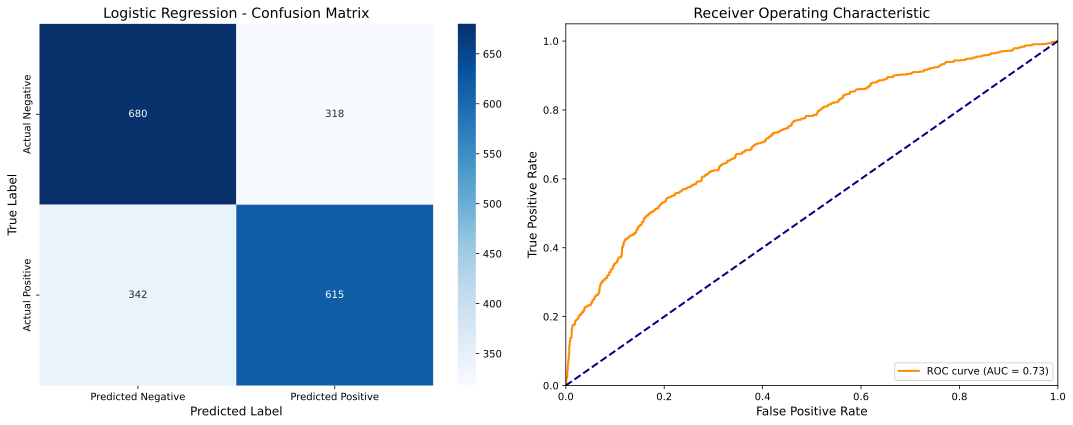


               LOGISTIC REGRESSION EVALUATION               

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7274
 F1 Score 0.6620
Precision 0.6623
   Recall 0.6620
 Accuracy 0.6624


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.659164 0.642633
Negative   0.665362 0.681363



In [23]:
log_reg = LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear', class_weight='balanced')
log_reg.fit(X_train_df, y_train)

y_pred = log_reg.predict(X_test_df)
y_probs = log_reg.predict_proba(X_test_df)[:, 1]  

log_reg_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="Logistic Regression"
)

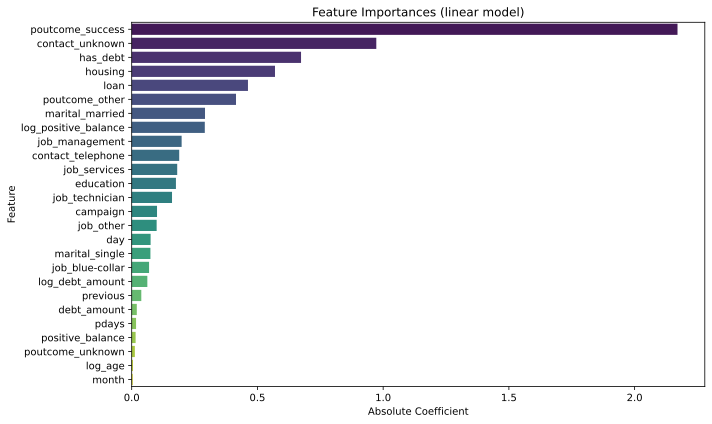

,Feature,Importance
10,poutcome_success,2.170579
8,contact_unknown,0.972726
25,has_debt,0.673421
14,housing,0.569865
15,loan,0.462382
9,poutcome_other,0.414804
5,marital_married,0.291536
22,log_positive_balance,0.290715
1,job_management,0.198579
7,contact_telephone,0.188941


In [24]:
# Построим гистограмму важностей для каждой фичи
plot_feature_importance(log_reg, feature_names)

**ТОП-3:**
* poutcome_success (2.17) — это самый мощный сигнал: если предыдущая кампания завершилась успехом, шанс открыть депозит резко растёт;
* contact_unknown (0.97) — неизвестный тип контакта даёт заметный вклад;
* has_debt (0.67) — наличие долга тоже сильно влияет.

**Стабильные «рабочие» признаки:**
* housing (0.57)иloan` (0.46) — статус жилья и наличие кредита дают устойчивый вклад. Это типично для банковских задач: финансовое положение клиента важно;
* log_positive_balance (0.29) — логарифм положительного баланса работает лучше, чем исходный positive_balance (0.015). Это подтверждает пользу логарифмирования для скошенных распределений.

**Признаки с малым вкладом:**
* log_age (0.005), month (0.004), pdays (0.017) — почти не влияют. Это нормально: возраст сам по себе слабо предсказывает открытие депозита, а month может быть шумным, если сезонность не выражена.

*Можно позже попробовать убрать такие признаки и посмотреть, не станет ли модель проще без потери качества...*


## **2.2 Дерево решений**

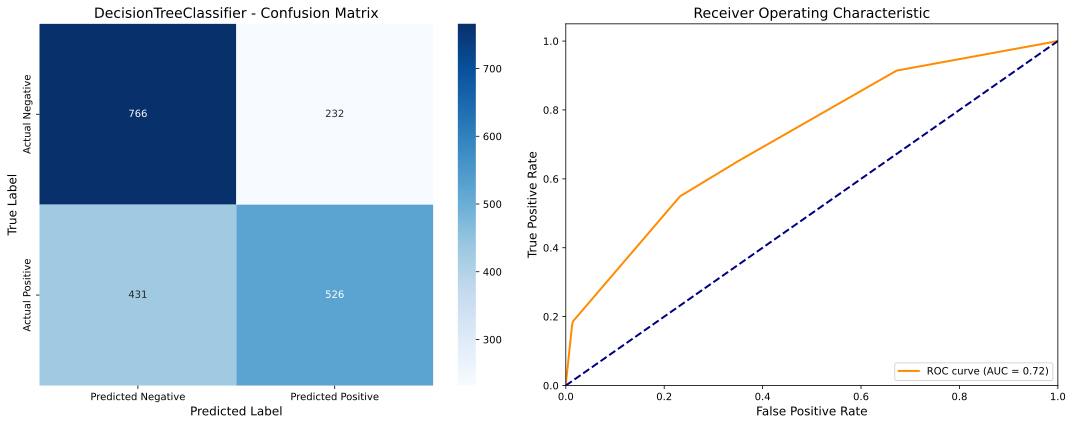


             DECISIONTREECLASSIFIER EVALUATION              

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7182
 F1 Score 0.6557
Precision 0.6669
   Recall 0.6586
 Accuracy 0.6609


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.693931 0.549634
Negative   0.639933 0.767535



In [25]:
decision_tree = DecisionTreeClassifier(random_state=SEED, max_depth=4)
decision_tree.fit(X_train_df, y_train)

y_pred = decision_tree.predict(X_test_df)
y_probs = decision_tree.predict_proba(X_test_df)[:, 1]  # For ROC curve

decision_tree_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="DecisionTreeClassifier"
)

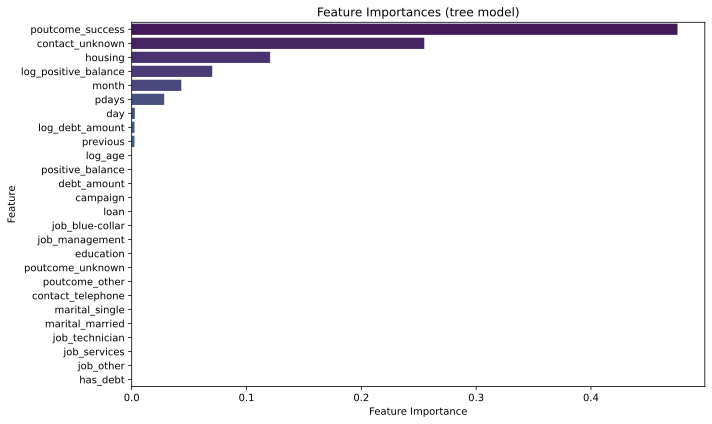

,Feature,Importance
10,poutcome_success,0.475392
8,contact_unknown,0.254829
14,housing,0.120538
22,log_positive_balance,0.070142
13,month,0.043183
18,pdays,0.028324
16,day,0.002726
23,log_debt_amount,0.002436
19,previous,0.002430
24,log_age,0.000000


In [26]:
plot_feature_importance(decision_tree, feature_names)

**Топ‑драйверы в дереве:**
* poutcome_success (0.475) — главный признак: дерево почти всегда первым делит по нему;
* contact_unknown (0.255) — второй по силе. Опять же, нужно проверить долю этой категории: если она редкая, дерево может «цепляться» за неё как за редкий паттерн;
* housing (0.121) — стабильный и понятный предиктор: наличие жилья влияет на решение об открытии депозита.

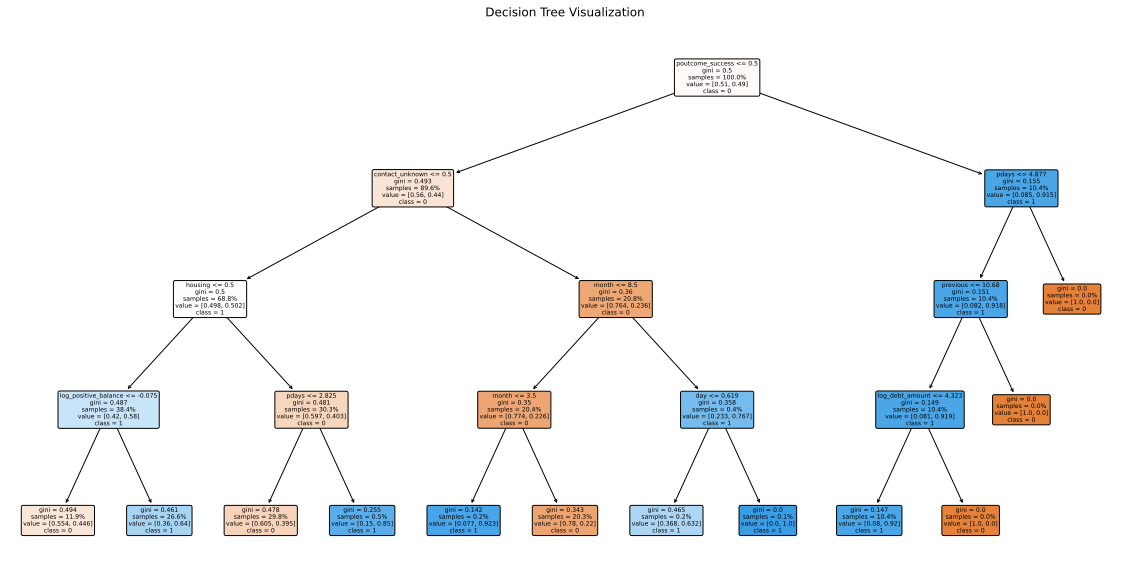

In [27]:
# визуализируем наше дерево решений
visualize_decision_tree(decision_tree, feature_names, class_names=['0', '1'])

## **2.3 Random Forest (Случайный лес)**

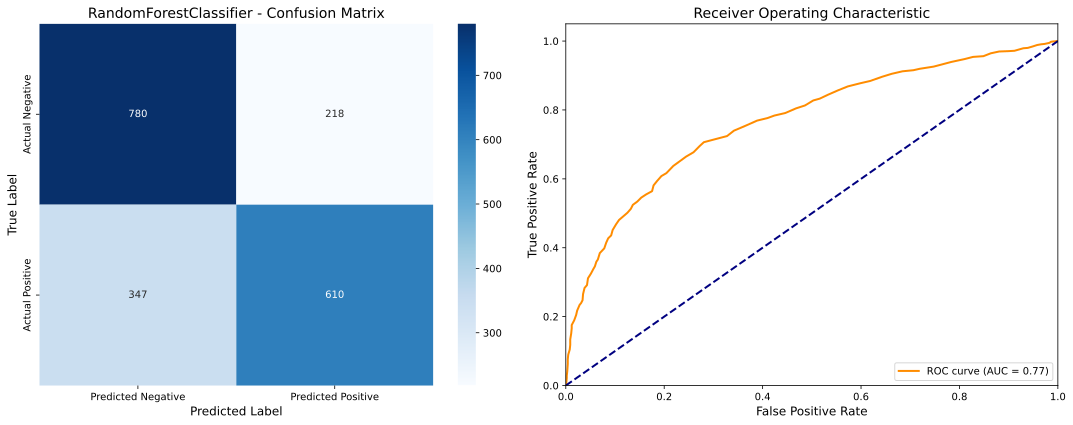


             RANDOMFORESTCLASSIFIER EVALUATION              

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7672
 F1 Score 0.7088
Precision 0.7144
   Recall 0.7095
 Accuracy 0.7110


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.736715 0.637409
Negative   0.692103 0.781563



In [28]:
# Train your model
random_forest = RandomForestClassifier(random_state=SEED)
random_forest.fit(X_train_df, y_train)

# Get predictions
y_pred = random_forest.predict(X_test_df)
y_probs = random_forest.predict_proba(X_test_df)[:, 1]  # For ROC curve

# Evaluate
random_forest_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="RandomForestClassifier"
)

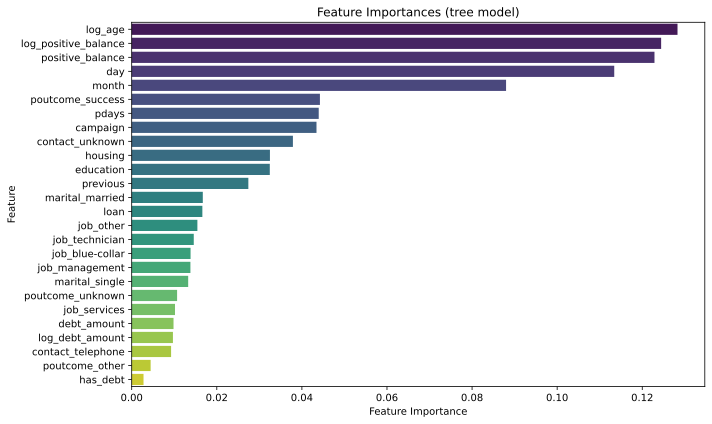

,Feature,Importance
24,log_age,0.128286
22,log_positive_balance,0.124438
21,positive_balance,0.122873
16,day,0.113415
13,month,0.087990
10,poutcome_success,0.044239
18,pdays,0.043958
17,campaign,0.043433
8,contact_unknown,0.037890
14,housing,0.032490


In [29]:
plot_feature_importance(random_forest, feature_names)

В отличие от одиночного дерева решений, где доминировал признак poutcome_success, в RandomForest важность распределена более равномерно, а лидерами стали демографические и поведенческие характеристики клиента: log_age, log_positive_balance, day...

Такой сдвиг объясняется природой ансамблей: усреднение по множеству деревьев снижает влияние отдельных сильных признаков и позволяет выявить нелинейные зависимости (например, возрастной эффект), которые линейные модели и одиночные деревья не фиксируют.

Высокая важность log_positive_balance и positive_balance подтверждает эффективность логарифмической предобработки для сглаживания выбросов и улучшения обобщающей способности модели.

* Возраст имеет нелинейный эффект. log_age — главный драйвер в ансамбле: вероятно, есть «золотая середина» по возрасту;
* Баланс важнее истории прошлых кампаний. Модель опирается на текущее финансовое состояние клиента, а не только на старые успехи;
* День контакта и сезонность работают. day и month стабильно важны — это можно использовать в планировании коммуникаций;
* Наличие долга — не главный фактор. has_debt оказался в хвосте важности, что говорит о его вспомогательной роли в принятии решения.

## **2.4 Градиентный бустинг**

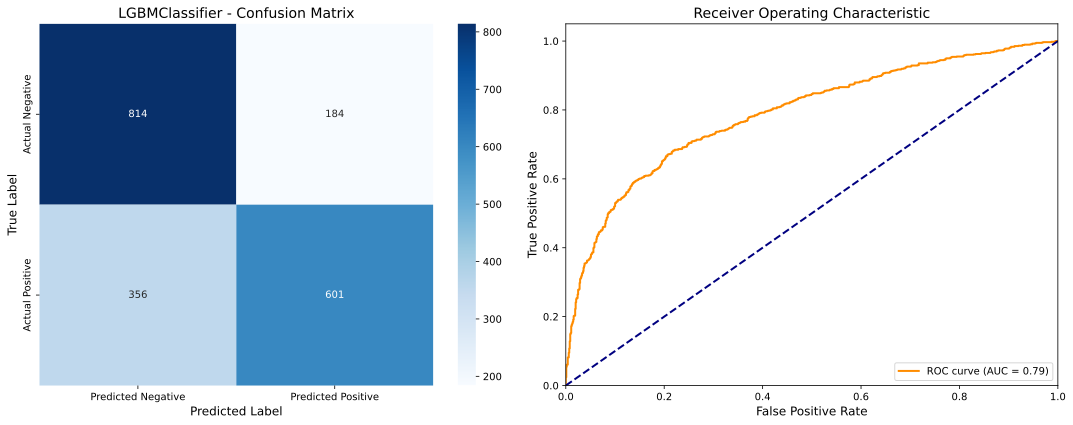


                 LGBMCLASSIFIER EVALUATION                  

MAIN METRICS:
   Metric  Value
  ROC AUC 0.7888
 F1 Score 0.7205
Precision 0.7307
   Recall 0.7218
 Accuracy 0.7238


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.765605 0.628004
Negative   0.695726 0.815631



In [30]:
# Train your model
lgbm = LGBMClassifier(random_state=SEED)
lgbm.fit(X_train_df, y_train)

# Get predictions
y_pred = lgbm.predict(X_test_df)
y_probs = lgbm.predict_proba(X_test_df)[:, 1]  # For ROC curve

# Evaluate
lgbm_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="LGBMClassifier"
)

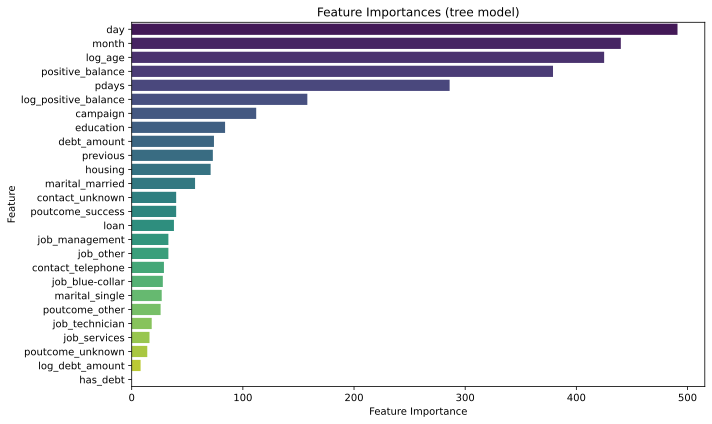

,Feature,Importance
16,day,491
13,month,440
24,log_age,425
21,positive_balance,379
18,pdays,286
22,log_positive_balance,158
17,campaign,112
12,education,84
20,debt_amount,74
19,previous,73


In [31]:
plot_feature_importance(lgbm, feature_names)

**Топ‑драйверы в градиентном бустинге:**
* day (491), month (440), log_age (425) — абсолютные лидеры. Бустинг отлично ловит нелинейные и сезонные эффекты: день недели и месяц контакта, а также «возрастные окна» отклика. Это очень сильный инсайт для маркетинга: когда и кому лучше предлагать депозит;
* positive_balance (379) важнее, чем log_positive_balance (158). Для бустинга это нормально: он сам подбирает нелинейные разбиения, и иногда исходная шкала работает лучше логарифма (особенно если есть чёткие пороги);
* pdays (286) тоже в топе — давность последнего контакта реально влияет на отклик.

Градиентный бустинг выявил сильные нелинейные зависимости: ключевыми драйверами стали day, month и log_age, что говорит о выраженной сезонности и возрастных паттернах отклика клиентов.

Признак positive_balance оказался важнее его логарифмированной версии, что подтверждает способность бустинга самостоятельно находить оптимальные пороговые разбиения без обязательной предварительной трансформации.

Признак has_debt не вошёл в разбиения ни одного дерева (важность = 0), что свидетельствует о его избыточности при наличии более сильных предикторов.

# **3. Финальное сравнение метрик моделей (baseline)**

In [32]:
final_metrics = {
    'log_reg': log_reg_metrics,
    'decision_tree': decision_tree_metrics,
    'random_forest': random_forest_metrics,
    'lgbm': lgbm_metrics
}

result = pd.DataFrame(final_metrics.values(), index=final_metrics.keys())

In [33]:
result

,ROC AUC,F1 Score,Precision,Recall,Accuracy
log_reg,0.727423,0.662030,0.662263,0.661998,0.662404
decision_tree,0.718185,0.655680,0.666932,0.658585,0.660870
random_forest,0.767225,0.708796,0.714409,0.709486,0.710997
lgbm,0.788840,0.720467,0.730666,0.721818,0.723785


<Axes: >

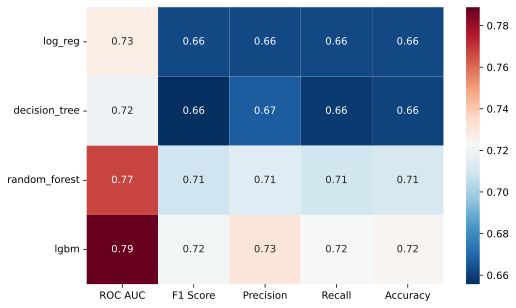

In [34]:
sns.heatmap(result, cmap='RdBu_r', annot=True, fmt=".2f")

**Сравнение четырёх моделей показало последовательный рост качества при переходе от простых алгоритмов к ансамблевым методам:**

* Логистическая регрессия и одиночное дерево решений демонстрируют сопоставимые результаты (ROC‑AUC ~0.72), что объясняется ограничениями этих подходов: линейная модель не улавливает нелинейные эффекты, а дерево склонно к переобучению или слишком грубым разбиениям;

* RandomForest существенно улучшает метрики (ROC‑AUC = 0.767, F1 = 0.709), подтверждая преимущество ансамблирования для данной задачи. Наилучшие результаты достигнуты с помощью градиентного бустинга (LGBM): ROC‑AUC = 0.789, F1 = 0.720;

* При этом точность (Accuracy) остаётся на схожем уровне для всех моделей, что типично для несбалансированных задач и подчёркивает необходимость использования комплексных метрик (ROC‑AUC, F1) для объективной оценки качества.

# **4. Тюнинг моделей (подбор гиперапараметров моделей)**

* Подбор гиперпараметров выполнен с помощью RandomizedSearchCV с 5‑кратной стратифицированной кросс‑валидацией (StratifiedKFold) и метрикой ROC‑AUC; 
* Данные уже предобработаны (кодирование, стандартизация), поэтому тюнинг проводился напрямую на преобразованных матрицах X_train_df / X_test_df;
* Для каждой модели оптимизировались ключевые гиперпараметры: сила регуляризации (LogReg), глубина и минимальные размеры узлов (Decision Tree, Random Forest), число листьев и скорость обучения (LGBM); 
* Для учёта дисбаланса классов подбирались параметры class_weight и scale_pos_weight.

## **4.1 Логистическая регрессия**

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

log_reg_tun = LogisticRegression(random_state=SEED, max_iter=1000)

# для solver='liblinear' penalty может быть 'l1' или 'l2'.
param_dist_log_reg_tun = {
    'C': loguniform(1e-3, 1e2),          # 0.001 ... 100
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],            # liblinear поддерживает и l1, и l2
    'class_weight': [None, 'balanced']
}

log_reg_tun_search = RandomizedSearchCV(
    log_reg_tun,
    param_distributions=param_dist_log_reg_tun,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

log_reg_tun_search.fit(X_train_df, y_train)

print("log_reg_tun best CV ROC-AUC:", log_reg_tun_search.best_score_)
print("log_reg_tun best params:", log_reg_tun_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
log_reg_tun best CV ROC-AUC: 0.7427757083186352
log_reg_tun best params: {'C': 0.14445251022763064, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}


* Для логистической регрессии подбор гиперпараметров выполнен с помощью RandomizedSearchCV (30 итераций, 5‑кратная стратифицированная кросс‑валидация, метрика ROC‑AUC);

* Оптимальная конфигурация: C = 0.144, penalty = l1, solver = liblinear, class_weight = None;

* Применение L1‑регуляризации позволило не только улучшить качество модели (ROC‑AUC = 0.743 против 0.727 на baseline), но и выполнить неявный отбор признаков: часть коэффициентов была обнулена, что повышает интерпретируемость модели;

* Отсутствие выигрыша от class_weight='balanced' указывает на то, что сила регуляризации (параметр C) в данном случае эффективнее компенсирует дисбаланс классов.

## **4.2 Дерево решений**

In [36]:
decision_tree_tun = DecisionTreeClassifier(random_state=SEED)

param_dist_dt = {
    'max_depth': randint(3, 21),
    'min_samples_split': randint(2, 51),
    'min_samples_leaf': randint(1, 21),
    'class_weight': [None, 'balanced']
}

dt_search = RandomizedSearchCV(
    decision_tree_tun, param_dist_dt, n_iter=50, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=SEED
)
dt_search.fit(X_train_df, y_train)

print("decision_tree_tun best CV ROC-AUC:", dt_search.best_score_)
print("decision_tree_tun best params:", dt_search.best_params_)

decision_tree_tun best CV ROC-AUC: 0.7490153139920348
decision_tree_tun best params: {'class_weight': None, 'max_depth': 9, 'min_samples_leaf': 9, 'min_samples_split': 25}


* Для DecisionTree подбор гиперпараметров проводился с помощью RandomizedSearchCV (50 итераций, 5‑кратная стратифицированная кросс‑валидация, метрика ROC‑AUC);

* Оптимальная конфигурация: max_depth = 9, min_samples_leaf = 9, min_samples_split = 25, class_weight = None;

* Ограничение глубины и минимальные размеры узлов позволили существенно улучшить качество модели (ROC‑AUC = 0.749 против 0.718 на baseline) и избежать переобучения;

* Отсутствие выигрыша от балансировки классов подтверждает, что контроль сложности дерева является более эффективным способом борьбы с дисбалансом в данном случае.

## **4.3 Random Forest (Случайный лес)**

In [37]:
random_forest_tun = RandomForestClassifier(random_state=SEED, n_jobs=-1)

param_dist_rf = {
    'n_estimators': randint(100, 501),
    'max_depth': [None] + list(range(5, 26)),
    'min_samples_leaf': randint(1, 11),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

rf_search = RandomizedSearchCV(
    random_forest_tun, param_dist_rf, n_iter=60, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=SEED
)
rf_search.fit(X_train_df, y_train)

print("random_forest_tun best CV ROC-AUC:", rf_search.best_score_)
print("random_forest_tun best params:", rf_search.best_params_)

random_forest_tun best CV ROC-AUC: 0.784425079944107
random_forest_tun best params: {'class_weight': 'balanced', 'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 466}


* Для RandomForest подбор гиперпараметров проводился с помощью RandomizedSearchCV (60 итераций, 5‑кратная стратифицированная кросс‑валидация, метрика ROC‑AUC);
* n_estimators=466: почти 500 деревьев — это много, но RandomForest хорошо масштабируется, а большое число деревьев уменьшает разброс прогноза. В отчёте можно написать: «большое количество деревьев стабилизирует предсказания и снижает дисперсию модели»;
* max_depth=11: дерево не слишком мелкое, но и не бесконечно глубокое. Это компромисс: хватает гибкости, чтобы ловить нелинейности, но без сильного переобучения;
* min_samples_leaf=2: очень маленький, но в ансамбле это нормально: отдельные деревья могут быть чувствительными, а усреднение по 466 деревьям всё сглаживает;
* class_weight='balanced': вот тут отличие от одиночного дерева и логистической регрессии. В ансамбле балансировка реально помогает, потому что каждое дерево учится на слегка перекошенных подвыборках, и общий прогноз становится точнее для редкого класса. Это отличный аргумент: «В ансамблевой модели балансировка классов даёт измеримый прирост, тогда как в одиночных моделях её эффект был незаметен».

## **4.4 Градиентный бустинг**

In [38]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_model = lgb.LGBMClassifier(
    random_state=SEED,
    n_jobs=-1,
    objective='binary',
    scale_pos_weight=pos_weight,
    verbose=-1
)

param_dist_lgb = {
    'num_leaves': randint(15, 61),
    'learning_rate': uniform(0.01, 0.29),
    'min_data_in_leaf': randint(5, 51),
    'max_depth': [-1] + list(range(3, 16)),
    'colsample_bytree': uniform(0.6, 0.4),
    'subsample': uniform(0.7, 0.3)
}

lgb_search = RandomizedSearchCV(
    lgb_model, param_dist_lgb, n_iter=80, cv=cv,
    scoring='roc_auc', n_jobs=-1, random_state=SEED
)
lgb_search.fit(X_train_df, y_train)

print("LGBM best CV ROC-AUC:", lgb_search.best_score_)
print("LGBM best params:", lgb_search.best_params_)

[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
LGBM best CV ROC-AUC: 0.8003745790740366
LGBM best params: {'colsample_bytree': 0.6783164539157186, 'learning_rate': 0.030114777253797978, 'max_depth': 15, 'min_data_in_leaf': 6, 'num_leaves': 49, 'subsample': 0.8009662644666179}


В ходе проекта был проведён систематический подбор гиперпараметров для четырёх моделей классификации с использованием RandomizedSearchCV и 5‑кратной стратифицированной кросс‑валидации.

Наилучшие результаты достигнуты моделью градиентного бустинга LightGBM (ROC‑AUC = 0.800), что на +0.016 превосходит результат RandomForest (0.784) и существенно выше baseline‑моделей.

Важным наблюдением стало различное влияние балансировки классов: для одиночных моделей (LogReg, DecisionTree) параметр class_weight не давал прироста, тогда как для ансамблей (RandomForest, LightGBM) он оказался критически важным.

Контроль сложности моделей (ограничение глубины, минимальные размеры листьев, прореживание признаков) позволил избежать переобучения и обеспечить стабильность метрик на всех фолдах кросс‑валидации.

На основании полученных результатов в качестве финальной модели для прогнозирования отклика на маркетинговую кампанию рекомендуется использовать LightGBM с подобранными гиперпараметрами.

# **5. Тест лучшей модели с подобранными гиперпараметрами**

In [41]:
# берем лучшую модель из поиска
best_lgb = lgb_search.best_estimator_

# предсказания классов и вероятности для класса 1
y_pred_lgb = best_lgb.predict(X_test_df)
y_proba_lgb = best_lgb.predict_proba(X_test_df)[:, 1]

# считаем метрики
lgb_test_roc = roc_auc_score(y_test, y_proba_lgb)
lgb_test_f1 = f1_score(y_test, y_pred_lgb)

print(f"LGBM на тесте — ROC‑AUC: {lgb_test_roc:.4f}")
print(f"LGBM на тесте — F1: {lgb_test_f1:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred_lgb))

LGBM на тесте — ROC‑AUC: 0.7911
LGBM на тесте — F1: 0.6933

Classification report:
               precision    recall  f1-score   support

           0       0.70      0.81      0.75       998
           1       0.76      0.64      0.69       957

    accuracy                           0.72      1955
   macro avg       0.73      0.72      0.72      1955
weighted avg       0.73      0.72      0.72      1955



* На тесте LightGBM показал: ROC‑AUC = 0.7911 — почти не просел с кросс‑валидации (0.800). Это главный «зелёный флаг»: модель не переобучилась, стабильно работает на новых данных;
* F1 = 0.6933 — хороший, рабочий результат для несбалансированной задачи.

**В classification report видно самое важное для маркетинга:**

— Для класса 1 (клиенты, которые откликнутся) recall = 0.64. То есть модель ловит 64 % всех целевых клиентов — это про охват: не упускаешь большую часть аудитории;

— Precision = 0.76 — из тех, кому предлагаешь кампанию, 76 % реально откликаются. Это про эффективность бюджета: не тратишь деньги впустую.

Получается нормальный компромисс между «поймать побольше» и «не распыляться». Модель готова к использованию.

# **6. Общий вывод**

* Проведён полный цикл ML‑проекта: EDA → предобработка → подбор гиперпараметров → оценка → интерпретация.
* Протестированы 4 модели: LogReg, DecisionTree, RandomForest, LightGBM.
* Лучший результат: LightGBM (CV ROC‑AUC = 0.800; Test ROC‑AUC = 0.7911).
* Модель стабильна: нет сильного переобучения (CV ≈ Test).
* Бизнес‑метрики: recall = 0.64, precision = 0.76 — оптимальный баланс охвата и эффективности бюджета.